# OffScript — Phase 1: Initial Data Exploration

Pulling and exploring Statcast pitch-by-pitch data for a curated 
set of MLB pitchers across the 2023 and 2024 seasons.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pybaseball import statcast_pitcher, playerid_lookup
from pybaseball import cache

# Enable caching — prevents re-downloading data on every run
cache.enable()

print("Imports successful")

Imports successful


In [8]:
# Look up Gerrit Cole's MLBAM ID
cole_lookup = playerid_lookup('Cole', 'Gerrit')
print(cole_lookup[['name_last', 'name_first', 'key_mlbam']])

Gathering player lookup table. This may take a moment.
  name_last name_first  key_mlbam
0      cole     gerrit     543037


In [9]:
# Pull 2023 and 2024 Statcast data for Gerrit Cole
cole_id = 543037

print("Pulling Statcast data for Gerrit Cole...")
cole_data = statcast_pitcher('2023-03-30', '2024-11-01', cole_id)

print(f"Total pitches: {len(cole_data)}")
print(f"Seasons: {cole_data['game_date'].min()} to {cole_data['game_date'].max()}")
print(f"Columns available: {len(cole_data.columns)}")

Pulling Statcast data for Gerrit Cole...
Gathering Player Data
Total pitches: 5318
Seasons: 2023-03-30 to 2024-10-30
Columns available: 118


In [10]:
cols_of_interest = [
    'game_date',
    'pitcher',
    'player_name',
    'pitch_type',
    'pitch_name',
    'release_speed',
    'pfx_x', 'pfx_z',
    'plate_x', 'plate_z',
    'balls', 'strikes',
    'on_1b', 'on_2b', 'on_3b',
    'stand',
    'p_throws',
    'events',
    'description',
    'inning',
    'home_score',
    'away_score'
]

cole_trimmed = cole_data[cols_of_interest].copy()

# Create count state column
cole_trimmed['count'] = (cole_trimmed['balls'].astype(str) + '-' + 
                         cole_trimmed['strikes'].astype(str))

# Create score differential column
cole_trimmed['score_diff'] = cole_trimmed['home_score'] - cole_trimmed['away_score']

print(cole_trimmed.shape)
print(cole_trimmed.dtypes)

(5318, 24)
game_date            str
pitcher            int64
player_name          str
pitch_type           str
pitch_name           str
release_speed    float64
pfx_x            float64
pfx_z            float64
plate_x          float64
plate_z          float64
balls              int64
strikes            int64
on_1b            float64
on_2b            float64
on_3b            float64
stand                str
p_throws             str
events               str
description          str
inning             int64
home_score         int64
away_score         int64
count                str
score_diff         int64
dtype: object


In [11]:
# Pitch type distribution
print("=== Pitch Type Distribution ===")
print(cole_trimmed['pitch_type'].value_counts())

print("\n=== Count State Distribution ===")
print(cole_trimmed['count'].value_counts().sort_index())

print("\n=== Batter Handedness ===")
print(cole_trimmed['stand'].value_counts())

print("\n=== Missing Values ===")
print(cole_trimmed.isnull().sum()[cole_trimmed.isnull().sum() > 0])

=== Pitch Type Distribution ===
pitch_type
FF    2659
SL     984
KC     767
FC     530
CH     327
SI      39
Name: count, dtype: int64

=== Count State Distribution ===
count
0-0    1347
0-1     742
0-2     385
1-0     441
1-1     527
1-2     537
2-0     147
2-1     259
2-2     504
3-0      42
3-1      91
3-2     296
Name: count, dtype: int64

=== Batter Handedness ===
stand
L    2808
R    2510
Name: count, dtype: int64

=== Missing Values ===
pitch_type         12
pitch_name         12
release_speed       9
pfx_x               9
pfx_z               9
plate_x            12
plate_z            12
on_1b            3927
on_2b            4569
on_3b            4969
events           3972
dtype: int64


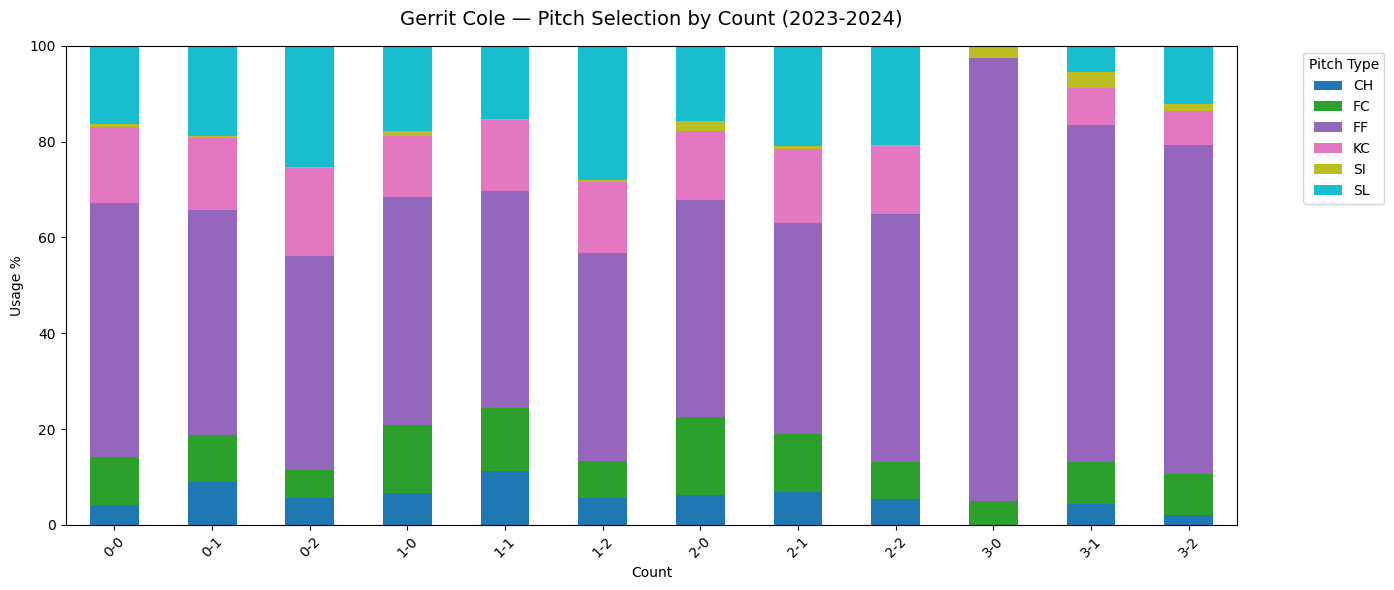

Chart saved to reports/figures/


In [12]:
# Pitch selection by count state
count_pitch = (
    cole_trimmed.groupby(['count', 'pitch_type'])
    .size()
    .reset_index(name='n')
)
count_pitch['pct'] = (count_pitch.groupby('count')['n']
                      .transform(lambda x: x / x.sum() * 100))

fig, ax = plt.subplots(figsize=(14, 6))
pivot = (count_pitch.pivot(index='count', columns='pitch_type', values='pct')
         .fillna(0))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

ax.set_title("Gerrit Cole — Pitch Selection by Count (2023-2024)", 
             fontsize=14, pad=15)
ax.set_ylabel("Usage %")
ax.set_xlabel("Count")
ax.legend(title="Pitch Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Save to reports folder
plt.savefig('../reports/figures/cole_pitch_selection_by_count.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/figures/")